# 04 — Test-Set Inference (seeds 1, 2, 42)

For each trained checkpoint (`seed_1`, `seed_2`, `seed_42`), run **pytorch** (fp32, fp16) and
**tensorrt** (fp32, fp16, fp8, int8, int4) across all input bit-depths on the **test set**
(`/home/pf4636/imagenet2`).

Results saved under `runs/final_runs/<seed>/`, aggregated as **mean ± std** across seeds.

In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
PYFILES = PROJECT_ROOT / "pyfiles"
if str(PYFILES) not in sys.path:
    sys.path.insert(0, str(PYFILES))

In [11]:
import json
import time
import torch
import torch.nn as nn
import pandas as pd

from src.config import ExperimentConfig, with_overrides, set_seed
from src.data import build_imagenet_dataset, build_imagenet_transform
from src.model import get_model
from src.eval import evaluate
from utils.precision import apply_precision
from utils.utils import load_runs, flatten_runs

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.3f}".format)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

torch: 2.10.0+cu130 | cuda: True


In [12]:
from dataclasses import replace
from torch.utils.data import DataLoader

CKPT_ROOT = PROJECT_ROOT / "training" / "checkpoints" / "fp32"
SEEDS = sorted([p.name for p in CKPT_ROOT.iterdir() if p.is_dir() and (p / "best.pth").exists()])
checkpoints = {seed: str(CKPT_ROOT / seed / "best.pth") for seed in SEEDS}

INPUT_BITS = [8, 4, 2, 1]
TEST_ROOT  = "/home/pf4636/imagenet2"

PYTORCH_PRECS  = ["fp32", "fp16"]
TENSORRT_PRECS = ["fp32", "fp16", "fp8", "int8", "int4"]

def seed_num(seed):
    return seed.split("_")[-1]

def build_test_loader(cfg: ExperimentConfig) -> DataLoader:
    test_cfg = replace(cfg, imagenet_path=TEST_ROOT)
    dataset = build_imagenet_dataset(test_cfg, split="val")
    pin_memory = str(cfg.device).startswith("cuda")
    return DataLoader(
        dataset,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
        drop_last=True,
    )

def run_on_test(cfg: ExperimentConfig, checkpoint_path=None):
    cfg = cfg.normalized()
    cfg.validate()
    set_seed(cfg)
    criterion = nn.CrossEntropyLoss()
    test_loader = build_test_loader(cfg)
    t0 = time.perf_counter()

    if cfg.backend == "pytorch":
        model = apply_precision(get_model(cfg, checkpoint_path=checkpoint_path), cfg)
        tracker = evaluate(model, test_loader, cfg, criterion=criterion)

    elif cfg.backend == "tensorrt":
        from trt.trt_infer import trt_evaluate
        from utils.onnx_exporter import ONNXExporter
        from trt.trt_builder import build_engine
        from src.runner import _get_trt_paths

        onnx_path, engine_path, _ = _get_trt_paths(cfg)
        if not onnx_path.exists():
            ONNXExporter(get_model(cfg, checkpoint_path=checkpoint_path), cfg.device, onnx_path).export_model(
                opset_version=cfg.trt_opset if cfg.trt_opset > 1 else 17,
                dynamic_batch=True,
                dummy_input_shape=(1, 3, 224, 224),
            )
        if not engine_path.exists():
            build_engine(
                onnx_path=onnx_path,
                engine_path=engine_path,
                precision=cfg.model_precision,
                batch_size=cfg.batch_size,
                workspace_mb=cfg.trt_workspace_mb,
            )
        tracker = trt_evaluate(engine_path, cfg, test_loader, criterion)

    else:
        raise ValueError(f"Unknown backend: {cfg.backend}")

    payload = {
        "status": "ok",
        "run_id": cfg.run_id(),
        "system": cfg.stamp(),
        "config": cfg.to_dict(),
        "results": tracker.summary(),
        "error": None,
        "total_eval_time_sec": round(time.perf_counter() - t0, 3),
    }
    return payload, tracker

def save_result(payload, out_dir):
    out_path = out_dir / payload["run_id"] / "result.json"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(payload, f, indent=2, sort_keys=True)
    return out_path

print(f"Seeds: {SEEDS}")
print(f"Checkpoints: {list(checkpoints.keys())}")
print(f"Input bits: {INPUT_BITS}")
print(f"Test set: {TEST_ROOT}")

Seeds: ['seed_1', 'seed_2', 'seed_42']
Checkpoints: ['seed_1', 'seed_2', 'seed_42']
Input bits: [8, 4, 2, 1]
Test set: /home/pf4636/imagenet2


## PyTorch — FP32

In [13]:
SKIP_EXISTING = True
pytorch_fp32_records = []

for seed, ckpt_path in checkpoints.items():
    print(f"\n  {seed}:")
    out_dir = Path(f"../runs/final_runs/{seed}").resolve()
    for bits in INPUT_BITS:
        cfg = with_overrides(ExperimentConfig(backend="pytorch", device="cuda", batch_size=1, seed=42, num_eval_batches=500), model_precision="fp32", input_quant_bits=bits)
        result_path = out_dir / cfg.run_id() / "result.json"

        if SKIP_EXISTING and result_path.exists():
            print(f"    b={bits}: exists, skipping")
            with open(result_path) as f:
                pytorch_fp32_records.append(json.load(f))
            continue

        payload, _ = run_on_test(cfg, checkpoint_path=ckpt_path)
        save_result(payload, out_dir)
        pytorch_fp32_records.append(payload)
        r = payload["results"]
        print(f"    b={bits}: top1={r['top1_acc']:.2f}%  top5={r['top5_acc']:.2f}%  infer={r['infer_ms_avg']:.2f}ms")


  seed_1:
[data] Filtered to 5000 samples across 100 classes.
Evaluating on 500 batches (first 30 are warmup)...
  --- Warmup complete (30 batches) — starting metric collection ---
  Batch [40/500] Top-1: 90.00% | Top-5: 100.00% | Infer: 2.94 ms/batch
  Batch [50/500] Top-1: 95.00% | Top-5: 100.00% | Infer: 2.81 ms/batch
  Batch [60/500] Top-1: 93.33% | Top-5: 100.00% | Infer: 2.72 ms/batch
  Batch [70/500] Top-1: 90.00% | Top-5: 97.50% | Infer: 2.82 ms/batch
  Batch [80/500] Top-1: 88.00% | Top-5: 98.00% | Infer: 2.83 ms/batch
  Batch [90/500] Top-1: 90.00% | Top-5: 98.33% | Infer: 2.90 ms/batch
  Batch [100/500] Top-1: 88.57% | Top-5: 98.57% | Infer: 2.88 ms/batch
  Batch [110/500] Top-1: 88.75% | Top-5: 98.75% | Infer: 2.91 ms/batch
  Batch [120/500] Top-1: 87.78% | Top-5: 97.78% | Infer: 2.91 ms/batch
  Batch [130/500] Top-1: 89.00% | Top-5: 98.00% | Infer: 2.94 ms/batch
  Batch [140/500] Top-1: 89.09% | Top-5: 98.18% | Infer: 2.89 ms/batch
  Batch [150/500] Top-1: 87.50% | Top-5:

## PyTorch — FP16

In [14]:
pytorch_fp16_records = []

for seed, ckpt_path in checkpoints.items():
    print(f"\n  {seed}:")
    out_dir = Path(f"../runs/final_runs/{seed}").resolve()
    for bits in INPUT_BITS:
        cfg = with_overrides(ExperimentConfig(backend="pytorch", device="cuda", batch_size=1, seed=42, num_eval_batches=500), model_precision="fp16", input_quant_bits=bits)
        result_path = out_dir / cfg.run_id() / "result.json"

        if SKIP_EXISTING and result_path.exists():
            print(f"    b={bits}: exists, skipping")
            with open(result_path) as f:
                pytorch_fp16_records.append(json.load(f))
            continue

        payload, _ = run_on_test(cfg, checkpoint_path=ckpt_path)
        save_result(payload, out_dir)
        pytorch_fp16_records.append(payload)
        r = payload["results"]
        print(f"    b={bits}: top1={r['top1_acc']:.2f}%  top5={r['top5_acc']:.2f}%  infer={r['infer_ms_avg']:.2f}ms")


  seed_1:
[data] Filtered to 5000 samples across 100 classes.
Evaluating on 500 batches (first 30 are warmup)...
  --- Warmup complete (30 batches) — starting metric collection ---
  Batch [40/500] Top-1: 90.00% | Top-5: 100.00% | Infer: 2.71 ms/batch
  Batch [50/500] Top-1: 95.00% | Top-5: 100.00% | Infer: 2.65 ms/batch
  Batch [60/500] Top-1: 93.33% | Top-5: 100.00% | Infer: 2.86 ms/batch
  Batch [70/500] Top-1: 90.00% | Top-5: 97.50% | Infer: 2.80 ms/batch
  Batch [80/500] Top-1: 88.00% | Top-5: 98.00% | Infer: 2.86 ms/batch
  Batch [90/500] Top-1: 90.00% | Top-5: 98.33% | Infer: 2.96 ms/batch
  Batch [100/500] Top-1: 88.57% | Top-5: 98.57% | Infer: 2.88 ms/batch
  Batch [110/500] Top-1: 88.75% | Top-5: 98.75% | Infer: 2.81 ms/batch
  Batch [120/500] Top-1: 87.78% | Top-5: 97.78% | Infer: 2.75 ms/batch
  Batch [130/500] Top-1: 89.00% | Top-5: 98.00% | Infer: 2.74 ms/batch
  Batch [140/500] Top-1: 89.09% | Top-5: 98.18% | Infer: 2.67 ms/batch
  Batch [150/500] Top-1: 87.50% | Top-5:

## TensorRT — FP32

In [15]:
def make_trt_cfg(seed, precision, bits):
    prefix = f"resnet_{seed_num(seed)}"
    return with_overrides(
        ExperimentConfig(
            backend="tensorrt",
            device="cuda",
            batch_size=1,
            seed=42,
            num_eval_batches=500,
            trt_static_shape=True,
            trt_workspace_mb=2048,
            onnx_root=str(PROJECT_ROOT / "onnx"),
            engine_root=str(PROJECT_ROOT / "engines" / seed),
            trt_onnx_prefix=prefix,
        ),
        model_precision=precision,
        input_quant_bits=bits,
    )

def run_trt_sweep(precision):
    records = []
    for seed, ckpt_path in checkpoints.items():
        print(f"\n  {seed}:")
        out_dir = Path(f"../runs/final_runs/{seed}").resolve()
        for bits in INPUT_BITS:
            cfg = make_trt_cfg(seed, precision, bits)
            result_path = out_dir / cfg.run_id() / "result.json"

            if SKIP_EXISTING and result_path.exists():
                print(f"    b={bits}: exists, skipping")
                with open(result_path) as f:
                    records.append(json.load(f))
                continue

            payload, _ = run_on_test(cfg, checkpoint_path=ckpt_path)
            save_result(payload, out_dir)
            records.append(payload)
            r = payload["results"]
            print(f"    b={bits}: top1={r['top1_acc']:.2f}%  top5={r['top5_acc']:.2f}%  infer={r['infer_ms_avg']:.2f}ms")
    return records

trt_fp32_records = run_trt_sweep("fp32")


  seed_1:
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/seed_1/resnet18_tensorrt_fp32_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 90.00%  Top-5: 100.00%  Infer: 1.10 ms/batch
  [50/500]  Top-1: 95.00%  Top-5: 100.00%  Infer: 1.14 ms/batch
  [60/500]  Top-1: 93.33%  Top-5: 100.00%  Infer: 1.15 ms/batch
  [70/500]  Top-1: 90.00%  Top-5: 97.50%  Infer: 1.14 ms/batch
  [80/500]  Top-1: 88.00%  Top-5: 98.00%  Infer: 1.15 ms/batch
  [90/500]  Top-1: 90.00%  Top-5: 98.33%  Infer: 1.15 ms/batch
  [100/500]  Top-1: 88.57%  Top-5: 98.57%  Infer: 1.13 ms/batch
  [110/500]  Top-1: 88.75%  Top-5: 98.75%  Infer: 1.13 ms/batch
  [120/500]  Top-1: 87.78%  Top-5: 97.78%  Infer: 1.12 ms/batch
  [130/500]  Top-1: 89.00%  Top-5: 

## TensorRT — FP16

In [16]:
trt_fp16_records = run_trt_sweep("fp16")


  seed_1:
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/seed_1/resnet18_tensorrt_fp16_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 90.00%  Top-5: 100.00%  Infer: 0.44 ms/batch
  [50/500]  Top-1: 95.00%  Top-5: 100.00%  Infer: 0.40 ms/batch
  [60/500]  Top-1: 93.33%  Top-5: 100.00%  Infer: 0.42 ms/batch
  [70/500]  Top-1: 90.00%  Top-5: 97.50%  Infer: 0.43 ms/batch
  [80/500]  Top-1: 88.00%  Top-5: 98.00%  Infer: 0.44 ms/batch
  [90/500]  Top-1: 90.00%  Top-5: 98.33%  Infer: 0.44 ms/batch
  [100/500]  Top-1: 88.57%  Top-5: 98.57%  Infer: 0.45 ms/batch
  [110/500]  Top-1: 88.75%  Top-5: 98.75%  Infer: 0.45 ms/batch
  [120/500]  Top-1: 87.78%  Top-5: 97.78%  Infer: 0.45 ms/batch
  [130/500]  Top-1: 89.00%  Top-5: 

## TensorRT — INT8

In [17]:
trt_int8_records = run_trt_sweep("int8")


  seed_1:
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/seed_1/resnet18_tensorrt_int8_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 90.00%  Top-5: 100.00%  Infer: 0.72 ms/batch
  [50/500]  Top-1: 95.00%  Top-5: 100.00%  Infer: 0.61 ms/batch
  [60/500]  Top-1: 93.33%  Top-5: 100.00%  Infer: 0.62 ms/batch
  [70/500]  Top-1: 90.00%  Top-5: 97.50%  Infer: 0.62 ms/batch
  [80/500]  Top-1: 88.00%  Top-5: 98.00%  Infer: 0.62 ms/batch
  [90/500]  Top-1: 90.00%  Top-5: 98.33%  Infer: 0.60 ms/batch
  [100/500]  Top-1: 88.57%  Top-5: 98.57%  Infer: 0.60 ms/batch
  [110/500]  Top-1: 88.75%  Top-5: 98.75%  Infer: 0.60 ms/batch
  [120/500]  Top-1: 87.78%  Top-5: 97.78%  Infer: 0.58 ms/batch
  [130/500]  Top-1: 89.00%  Top-5: 

## TensorRT — FP8

In [18]:
trt_fp8_records = run_trt_sweep("fp8")


  seed_1:
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/seed_1/resnet18_tensorrt_fp8_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 90.00%  Top-5: 100.00%  Infer: 0.68 ms/batch
  [50/500]  Top-1: 95.00%  Top-5: 100.00%  Infer: 0.63 ms/batch
  [60/500]  Top-1: 93.33%  Top-5: 100.00%  Infer: 0.60 ms/batch
  [70/500]  Top-1: 90.00%  Top-5: 97.50%  Infer: 0.64 ms/batch
  [80/500]  Top-1: 88.00%  Top-5: 98.00%  Infer: 0.65 ms/batch
  [90/500]  Top-1: 90.00%  Top-5: 98.33%  Infer: 0.66 ms/batch
  [100/500]  Top-1: 88.57%  Top-5: 98.57%  Infer: 0.64 ms/batch
  [110/500]  Top-1: 88.75%  Top-5: 98.75%  Infer: 0.64 ms/batch
  [120/500]  Top-1: 87.78%  Top-5: 97.78%  Infer: 0.63 ms/batch
  [130/500]  Top-1: 89.00%  Top-5: 9

## TensorRT — INT4

In [19]:
trt_int4_records = run_trt_sweep("int4")


  seed_1:
[data] Filtered to 5000 samples across 100 classes.
[trt_infer] Engine: /home/pf4636/code/resnet/quantized_resnets/engines/seed_1/resnet18_tensorrt_int4_in8b_cuda_bs1.engine
[trt_infer] Input: 'images'  Output: 'logits'  Dynamic batch: False
[trt_infer] Evaluating 500 batches (first 30 are warmup) ...
[trt_infer] --- Warmup complete (30 batches) — starting metric collection ---
  [40/500]  Top-1: 90.00%  Top-5: 100.00%  Infer: 0.48 ms/batch
  [50/500]  Top-1: 95.00%  Top-5: 100.00%  Infer: 0.51 ms/batch
  [60/500]  Top-1: 93.33%  Top-5: 100.00%  Infer: 0.50 ms/batch
  [70/500]  Top-1: 90.00%  Top-5: 97.50%  Infer: 0.49 ms/batch
  [80/500]  Top-1: 88.00%  Top-5: 98.00%  Infer: 0.48 ms/batch
  [90/500]  Top-1: 90.00%  Top-5: 98.33%  Infer: 0.48 ms/batch
  [100/500]  Top-1: 88.57%  Top-5: 98.57%  Infer: 0.49 ms/batch
  [110/500]  Top-1: 88.75%  Top-5: 98.75%  Infer: 0.47 ms/batch
  [120/500]  Top-1: 87.78%  Top-5: 97.78%  Infer: 0.48 ms/batch
  [130/500]  Top-1: 89.00%  Top-5: 

## All Results (per seed)

In [20]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SKIP_BACKEND = {"torchao_cpu_ptq"}

rows = []
for seed in SEEDS:
    seed_dir = Path(f"../runs/final_runs/{seed}").resolve()
    runs = load_runs(str(seed_dir), status="ok")
    for r in flatten_runs(runs):
        if r.get("cfg.backend") in SKIP_BACKEND:
            continue
        r["seed"] = seed
        rows.append(r)

df = pd.DataFrame(rows)
df["backend"]    = df["cfg.backend"]
df["precision"]  = df["cfg.model_precision"]
df["input_bits"] = df["cfg.input_quant_bits"].astype(int)
df["top1"]       = df["res.top1_acc"]
df["top5"]       = df["res.top5_acc"]
df["lat_ms"]     = df["res.infer_ms_avg"]
df["lat_std"]    = df["res.infer_ms_std"]
df["tput"]       = df["res.throughput_infer_sps"]

print(f"{len(df)} total runs across {df['seed'].nunique()} seeds")

display_cols = [
    "seed", "cfg.backend", "cfg.model_precision", "cfg.input_quant_bits",
    "res.top1_acc", "res.top5_acc", "res.infer_ms_avg", "res.throughput_infer_sps",
]
df[display_cols].sort_values(
    ["seed", "cfg.backend", "cfg.model_precision", "cfg.input_quant_bits"], ascending=[True, True, True, False]
).reset_index(drop=True)

84 total runs across 3 seeds


,seed,cfg.backend,cfg.model_precision,cfg.input_quant_bits,res.top1_acc,res.top5_acc,res.infer_ms_avg,res.throughput_infer_sps
0,seed_1,pytorch,fp16,8,79.787,95.957,2.773,360.652
1,seed_1,pytorch,fp16,4,79.362,95.745,3.098,322.839
2,seed_1,pytorch,fp16,2,54.681,79.787,3.126,319.884
3,seed_1,pytorch,fp16,1,32.766,58.723,3.111,321.423
4,seed_1,pytorch,fp32,8,79.787,95.957,3.044,328.496
...,...,...,...,...,...,...,...,...
79,seed_42,tensorrt,int4,1,27.660,58.511,0.485,2061.678
80,seed_42,tensorrt,int8,8,81.702,97.660,0.659,1517.758
81,seed_42,tensorrt,int8,4,81.915,97.234,0.734,1361.969
82,seed_42,tensorrt,int8,2,56.170,82.979,0.634,1577.658


## Averaged Results (across seeds)

In [21]:
group_cols = ["backend", "precision", "input_bits"]

table = (
    df.groupby(group_cols)
    .agg(
        top1_mean=("top1", "mean"),
        top1_std=("top1", "std"),
        top5_mean=("top5", "mean"),
        top5_std=("top5", "std"),
        lat_ms_mean=("lat_ms", "mean"),
        lat_ms_std=("lat_ms", "std"),
        tput_mean=("tput", "mean"),
        tput_std=("tput", "std"),
        n_seeds=("seed", "count"),
    )
    .reset_index()
    .sort_values(["backend", "input_bits", "precision"])
    .reset_index(drop=True)
)

table

,backend,precision,input_bits,top1_mean,top1_std,top5_mean,top5_std,lat_ms_mean,lat_ms_std,tput_mean,tput_std,n_seeds
0,pytorch,fp16,1,30.426,2.580,59.858,1.071,2.937,0.237,342.000,28.774,3
1,pytorch,fp32,1,30.426,2.580,59.716,1.071,2.865,0.092,349.341,11.407,3
2,pytorch,fp16,2,54.397,1.931,80.426,2.096,3.108,0.019,321.769,1.952,3
3,pytorch,fp32,2,54.397,1.931,80.426,2.096,2.967,0.083,337.211,9.346,3
4,pytorch,fp16,4,80.355,0.959,96.241,0.684,2.998,0.132,334.050,15.054,3
5,pytorch,fp32,4,80.213,0.851,96.241,0.684,2.922,0.061,342.314,7.074,3
6,pytorch,fp16,8,81.064,1.185,96.738,1.005,3.006,0.222,333.855,24.994,3
7,pytorch,fp32,8,81.135,1.282,96.667,0.886,3.017,0.206,332.532,23.039,3
8,tensorrt,fp16,1,30.496,2.466,59.787,1.126,0.498,0.025,2013.150,98.473,3
9,tensorrt,fp32,1,30.426,2.580,59.787,0.975,0.969,0.039,1033.078,41.310,3


In [22]:
fmt = table.copy()
fmt["Top-1 (%)"]    = fmt.apply(lambda r: f"{r['top1_mean']:.2f} ± {r['top1_std']:.2f}", axis=1)
fmt["Top-5 (%)"]    = fmt.apply(lambda r: f"{r['top5_mean']:.2f} ± {r['top5_std']:.2f}", axis=1)
fmt["Latency (ms)"] = fmt.apply(lambda r: f"{r['lat_ms_mean']:.3f} ± {r['lat_ms_std']:.3f}", axis=1)
fmt["Throughput"]    = fmt.apply(lambda r: f"{r['tput_mean']:.1f} ± {r['tput_std']:.1f}", axis=1)

display_cols = ["backend", "precision", "input_bits", "Top-1 (%)", "Top-5 (%)", "Latency (ms)", "Throughput", "n_seeds"]
fmt[display_cols]

,backend,precision,input_bits,Top-1 (%),Top-5 (%),Latency (ms),Throughput,n_seeds
0,pytorch,fp16,1,30.43 ± 2.58,59.86 ± 1.07,2.937 ± 0.237,342.0 ± 28.8,3
1,pytorch,fp32,1,30.43 ± 2.58,59.72 ± 1.07,2.865 ± 0.092,349.3 ± 11.4,3
2,pytorch,fp16,2,54.40 ± 1.93,80.43 ± 2.10,3.108 ± 0.019,321.8 ± 2.0,3
3,pytorch,fp32,2,54.40 ± 1.93,80.43 ± 2.10,2.967 ± 0.083,337.2 ± 9.3,3
4,pytorch,fp16,4,80.35 ± 0.96,96.24 ± 0.68,2.998 ± 0.132,334.0 ± 15.1,3
5,pytorch,fp32,4,80.21 ± 0.85,96.24 ± 0.68,2.922 ± 0.061,342.3 ± 7.1,3
6,pytorch,fp16,8,81.06 ± 1.18,96.74 ± 1.01,3.006 ± 0.222,333.9 ± 25.0,3
7,pytorch,fp32,8,81.13 ± 1.28,96.67 ± 0.89,3.017 ± 0.206,332.5 ± 23.0,3
8,tensorrt,fp16,1,30.50 ± 2.47,59.79 ± 1.13,0.498 ± 0.025,2013.2 ± 98.5,3
9,tensorrt,fp32,1,30.43 ± 2.58,59.79 ± 0.98,0.969 ± 0.039,1033.1 ± 41.3,3


### tensorrt_int8_in8b
  * Mean:   0.796 ms
  * Std:    0.276 ms
  * Min:    0.465 ms
  * Max:    2.010 ms
  * P50:    0.688 ms
  * P95:    1.389 ms
  * P99:    1.561 ms

### pytorch_fp32_in8b
  * Mean:   2.943 ms
  * Std:    1.244 ms
  * Min:    1.249 ms
  * Max:    6.554 ms
  * P50:    2.787 ms
  * P95:    5.169 ms
  * P99:    5.707 ms


### tensorrt_fp32_in4b
  * Mean:   0.982 ms
  * Std:    0.136 ms
  * Min:    0.800 ms
  * Max:    2.140 ms
  * P50:    0.931 ms
  * P95:    1.271 ms
  * P99:    1.388 ms

In [34]:
import pandas as pd

df = pd.read_json("/home/pf4636/code/resnet/quantized_resnets/results/test_avg_results.json")
df


,backend,precision,input_bits,top1_mean,top1_std,top5_mean,top5_std,lat_ms_mean,lat_ms_std,tput_mean,tput_std,n_seeds,lat_10k_std,lat_10k_bench
0,pytorch,fp16,1,30.426,2.580,59.858,1.071,2.937,0.237,342.000,28.774,3,1.244,pytorch_fp32_in8b
1,pytorch,fp32,1,30.426,2.580,59.716,1.071,2.865,0.092,349.341,11.407,3,1.244,pytorch_fp32_in8b
2,pytorch,fp16,2,54.397,1.931,80.426,2.096,3.108,0.019,321.769,1.952,3,1.244,pytorch_fp32_in8b
3,pytorch,fp32,2,54.397,1.931,80.426,2.096,2.967,0.083,337.211,9.346,3,1.244,pytorch_fp32_in8b
4,pytorch,fp16,4,80.355,0.959,96.241,0.684,2.998,0.132,334.050,15.054,3,1.244,pytorch_fp32_in8b
5,pytorch,fp32,4,80.213,0.851,96.241,0.684,2.922,0.061,342.314,7.074,3,1.244,pytorch_fp32_in8b
6,pytorch,fp16,8,81.064,1.185,96.738,1.005,3.006,0.222,333.855,24.994,3,1.244,pytorch_fp32_in8b
7,pytorch,fp32,8,81.135,1.282,96.667,0.886,3.017,0.206,332.532,23.039,3,1.244,pytorch_fp32_in8b
8,tensorrt,fp16,1,30.496,2.466,59.787,1.126,0.498,0.025,2013.150,98.473,3,0.276,tensorrt_int8_in8b
9,tensorrt,fp32,1,30.426,2.580,59.787,0.975,0.969,0.039,1033.078,41.310,3,0.136,tensorrt_fp32_in4b


## Plots

In [23]:
BACKENDS = ["pytorch", "tensorrt"]
COLS     = 2
eb_kw    = dict(capsize=3, capthick=0.8, elinewidth=0.8, linewidth=0)

BIT_PALETTE = {1: "#1f77b4", 2: "#d62728", 4: "#2ca02c", 8: "#9467bd"}

PREC_PALETTE = {
    "fp8": "#1f77b4", "fp16": "#d62728", "fp32": "#2ca02c",
    "int4": "#9467bd", "int8": "#8c564b",
}

def make_figure(backend, n):
    nrows = math.ceil(n / COLS)
    fig, axes = plt.subplots(
        nrows, COLS, figsize=(4.5 * COLS, 3.8 * nrows),
        constrained_layout=True, squeeze=False,
    )
    fig.suptitle(backend, fontsize=12, fontweight="normal", x=0.5, ha="center", y=1.04)
    fig.set_constrained_layout_pads(wspace=0.15, hspace=0.1)
    ax_flat = axes.flatten()
    for idx in range(n, len(ax_flat)):
        ax_flat[idx].set_visible(False)
    return ax_flat

def draw_bars(ax, grp, x_col, palette, val_col="lat_ms_mean", err_col="lat_ms_std"):
    x_vals = grp[x_col].tolist()
    x_pos  = np.arange(len(x_vals))
    for xi, (_, row) in enumerate(grp.iterrows()):
        c = palette.get(row[x_col] if isinstance(row[x_col], str) else int(row[x_col]), "#7f7f7f")
        ax.bar(xi, row[val_col], color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.errorbar(xi, row[val_col], yerr=row[err_col],
                    fmt="none", ecolor=c, **eb_kw)
        ax.text(xi, row[val_col] * 0.02, f"{row[val_col]:.3f}",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_ylim(0, (grp[val_col] + grp[err_col]).max() * 1.25)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

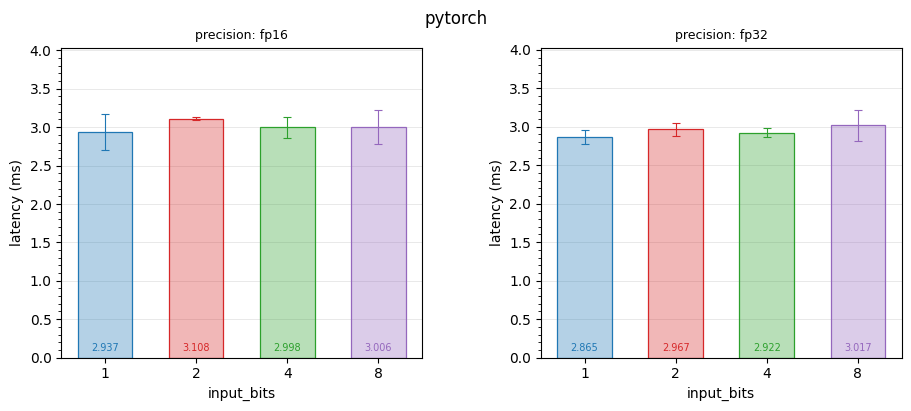

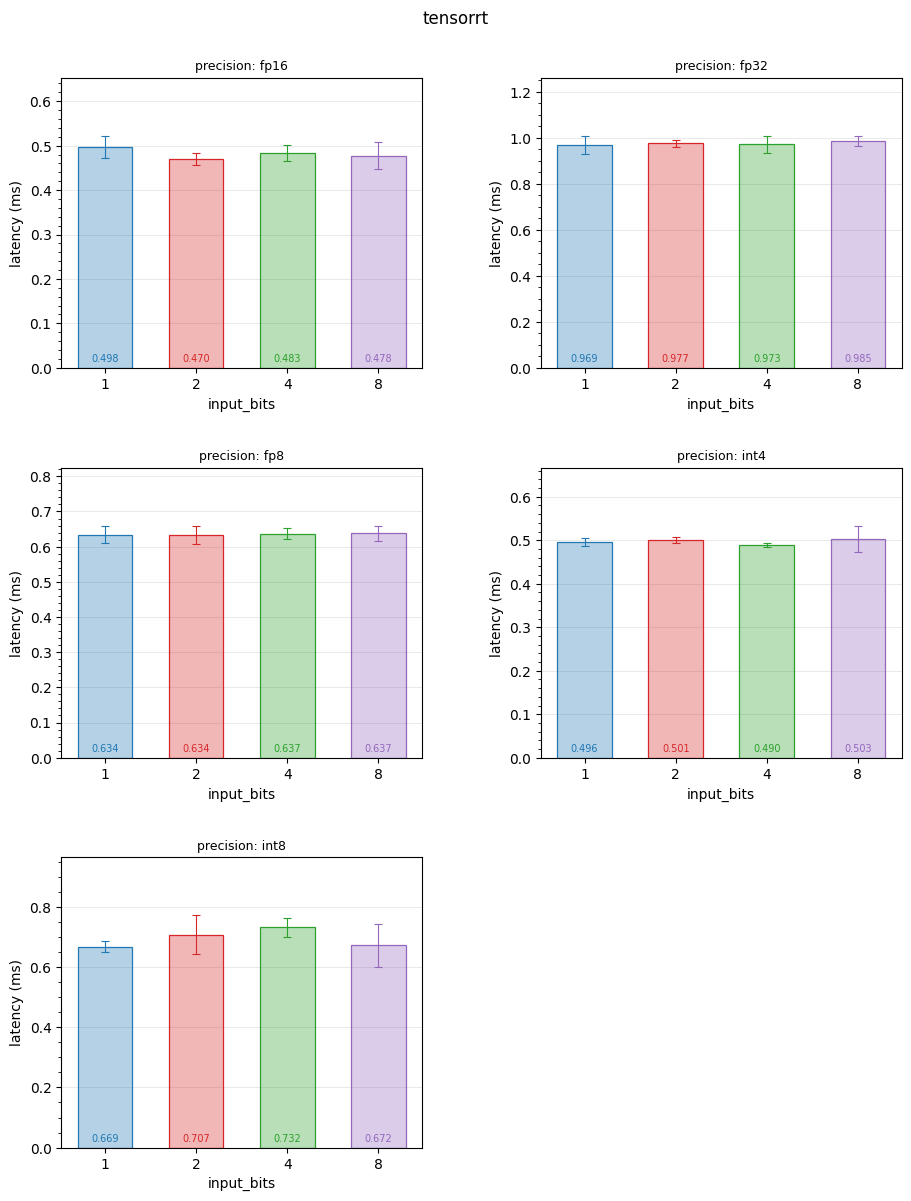

In [24]:
# Plot 1 — latency vs input quantization bits
for backend in BACKENDS:
    backend_data = table[table["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = (
            backend_data[backend_data["precision"] == prec]
            .sort_values("input_bits")
        )
        if grp.empty:
            ax.set_visible(False)
            continue

        grp = grp.copy()
        grp["input_bits"] = grp["input_bits"].astype(int)
        draw_bars(ax, grp, x_col="input_bits", palette=BIT_PALETTE)
        ax.set_xlabel("input_bits")
        ax.set_ylabel("latency (ms)")
        ax.set_title(f"precision: {prec}", fontsize=9)

    plt.show()

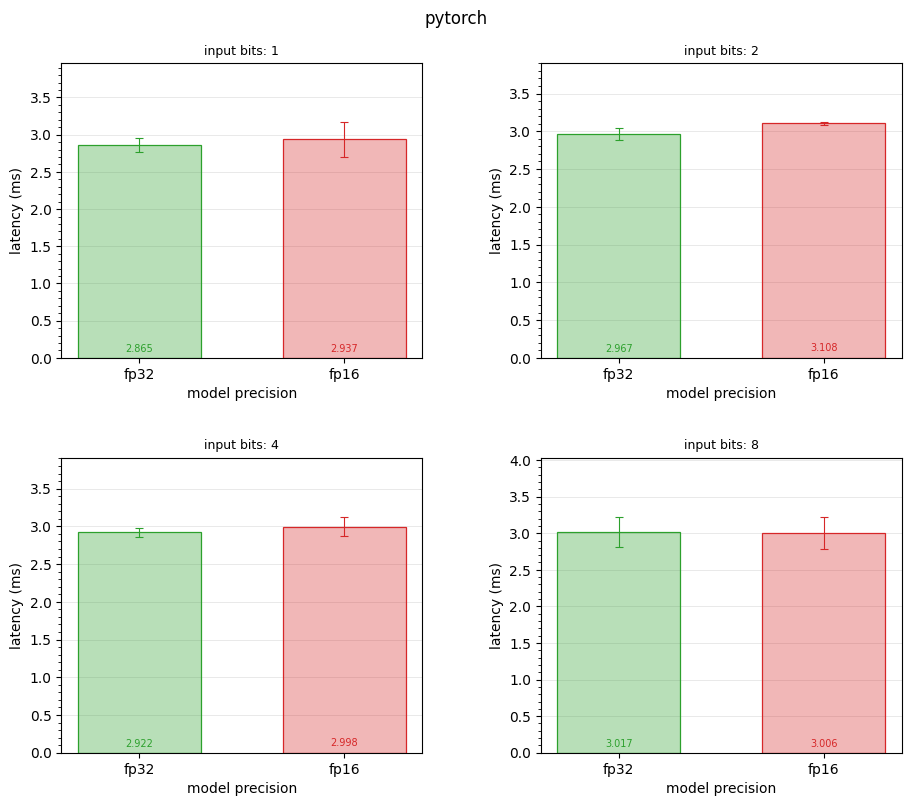

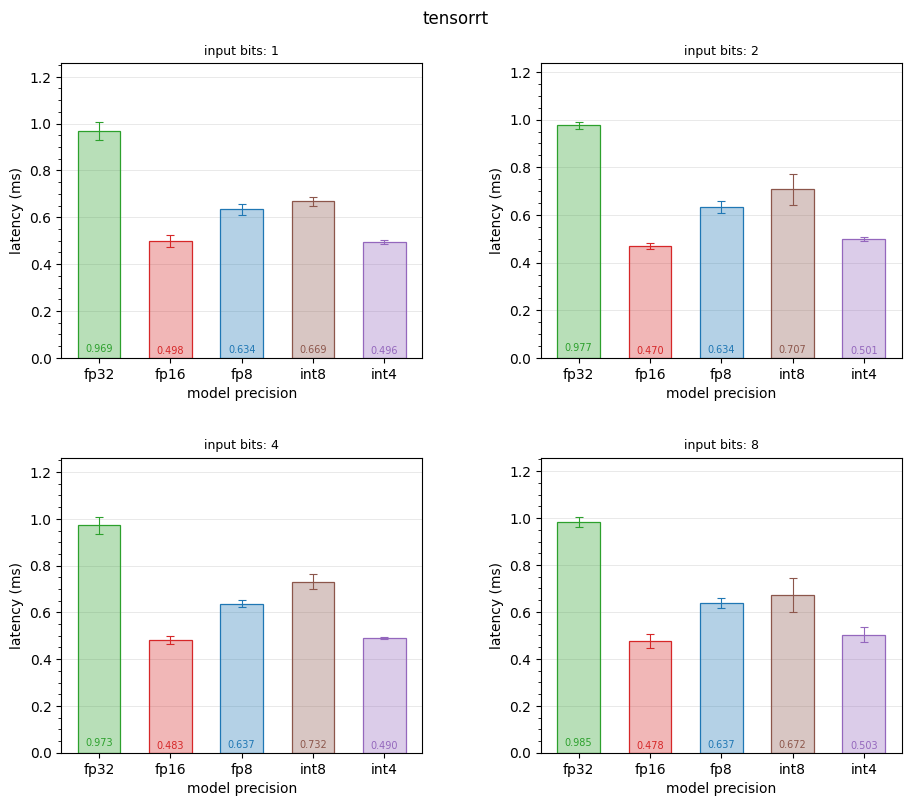

In [25]:
# Plot 2 — latency vs model precision
for backend in BACKENDS:
    backend_data = table[table["backend"] == backend]
    active_bits = sorted(backend_data["input_bits"].dropna().astype(int).unique())
    n = len(active_bits)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, bits in zip(ax_flat, active_bits):
        PREC_ORDER = ["fp32", "fp16", "fp8", "int8", "int4"]
        grp = backend_data[backend_data["input_bits"] == bits]
        grp = grp.set_index("precision").reindex(PREC_ORDER).dropna(subset=["lat_ms_mean"]).reset_index()
        if grp.empty:
            ax.set_visible(False)
            continue

        draw_bars(ax, grp, x_col="precision", palette=PREC_PALETTE)
        ax.set_xlabel("model precision")
        ax.set_ylabel("latency (ms)")
        ax.set_title(f"input bits: {bits}", fontsize=9)

    plt.show()

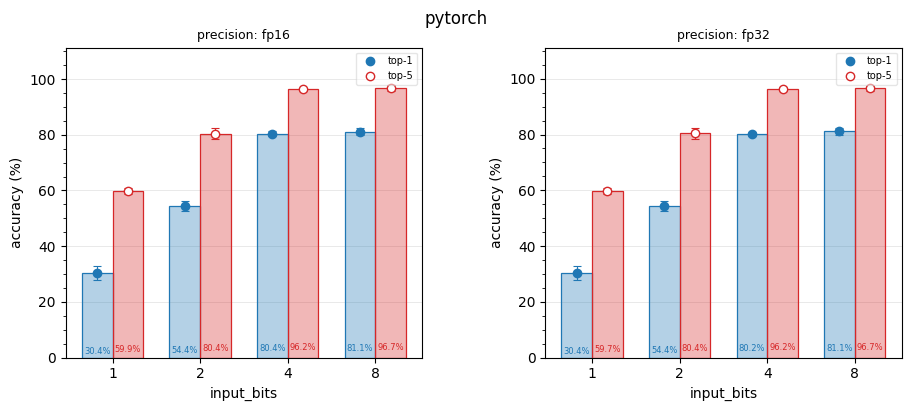

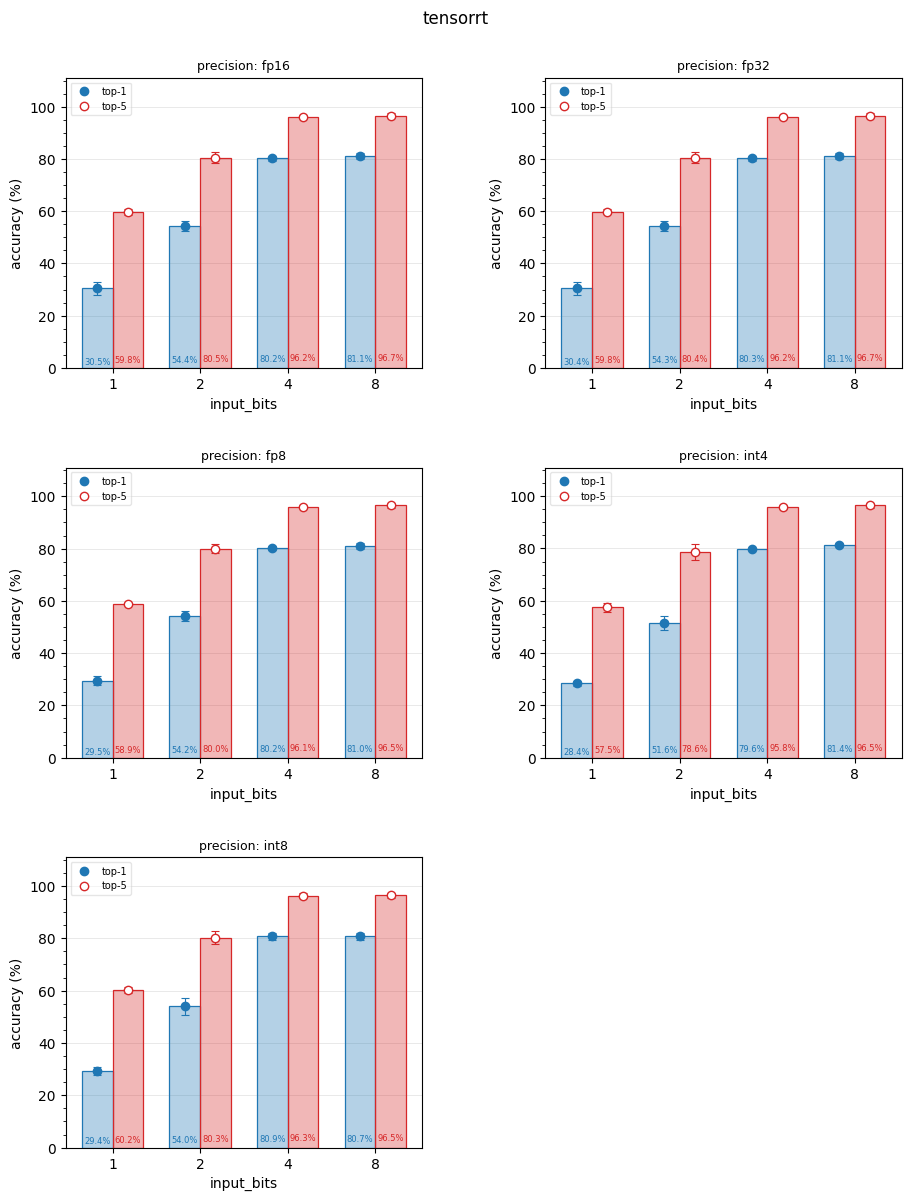

In [26]:
# Plot 3 — Top-1 & Top-5 accuracy vs input quantization bits
for backend in BACKENDS:
    backend_data = table[table["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(backend, n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = (
            backend_data[backend_data["precision"] == prec]
            .sort_values("input_bits")
        )
        if grp.empty:
            ax.set_visible(False)
            continue

        bits  = grp["input_bits"].astype(int).tolist()
        x_pos = np.arange(len(bits))
        width = 0.35

        ax.bar(x_pos - width/2, grp["top1_mean"], width=width,
               color="#1f77b4" + "55", edgecolor="#1f77b4", linewidth=0.9, zorder=2)
        ax.errorbar(x_pos - width/2, grp["top1_mean"], yerr=grp["top1_std"],
                    fmt="none", ecolor="#1f77b4", **eb_kw)
        ax.bar(x_pos + width/2, grp["top5_mean"], width=width,
               color="#d62728" + "55", edgecolor="#d62728", linewidth=0.9, zorder=2)
        ax.errorbar(x_pos + width/2, grp["top5_mean"], yerr=grp["top5_std"],
                    fmt="none", ecolor="#d62728", **eb_kw)

        ax.plot(x_pos - width/2, grp["top1_mean"], color="#1f77b4",
                marker="o", linestyle="none", markersize=6, label="top-1", zorder=3)
        ax.plot(x_pos + width/2, grp["top5_mean"], color="#d62728",
                marker="o", linestyle="none", markersize=6,
                markerfacecolor="white", label="top-5", zorder=3)

        for xi, (_, row) in enumerate(grp.iterrows()):
            ax.text(xi - width/2, row["top1_mean"] * 0.02, f"{row['top1_mean']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#1f77b4", zorder=4)
            ax.text(xi + width/2, row["top5_mean"] * 0.02, f"{row['top5_mean']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#d62728", zorder=4)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(b) for b in bits])
        ax.set_xlabel("input_bits")
        ax.set_ylabel("accuracy (%)")
        ax.set_title(f"precision: {prec}", fontsize=9)
        ax.set_ylim(0, grp[["top1_mean", "top5_mean"]].max().max() * 1.15)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
        ax.legend(fontsize=7, framealpha=0.5)

    plt.show()

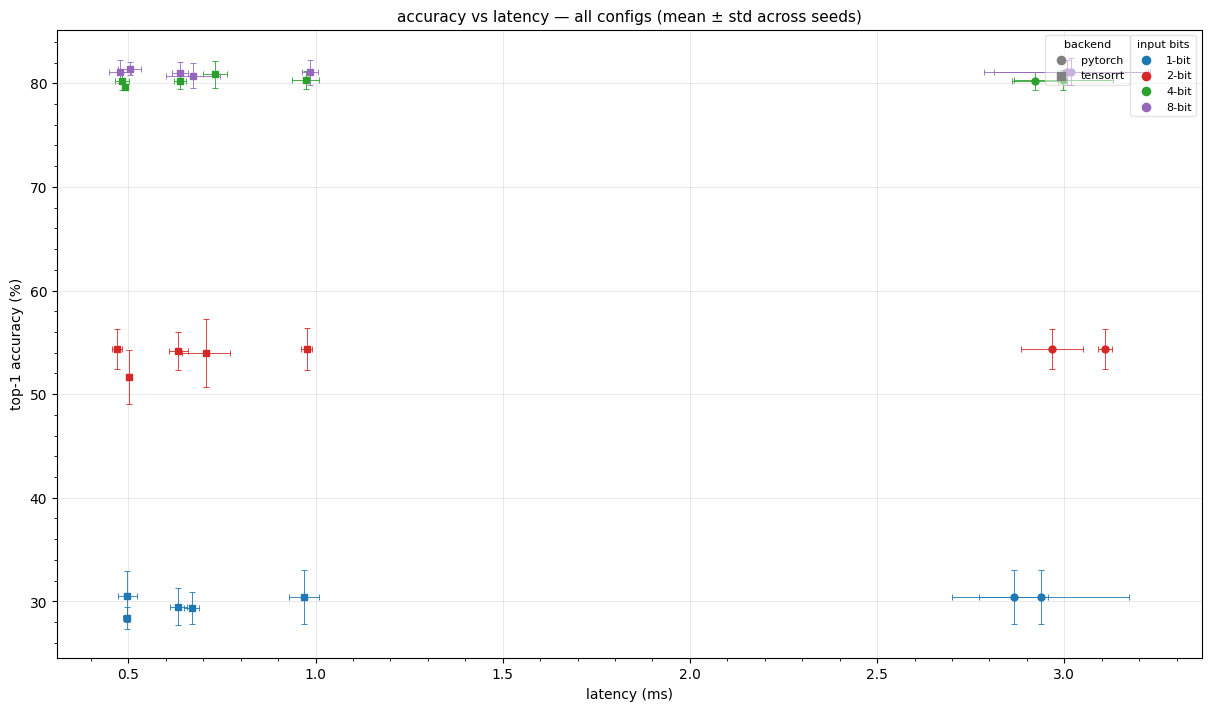

In [27]:
# Plot 4 — Top-1 accuracy vs latency scatter (all configs)
BACKEND_MARKERS = {"pytorch": "o", "tensorrt": "s"}

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for _, row in table.iterrows():
    marker = BACKEND_MARKERS.get(row["backend"], "o")
    bits   = int(row["input_bits"])
    color  = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.errorbar(row["lat_ms_mean"], row["top1_mean"],
                xerr=row["lat_ms_std"], yerr=row["top1_std"],
                fmt=marker, color=color, markersize=5,
                elinewidth=0.6, capsize=2, capthick=0.6, zorder=3)

ax.set_xlabel("latency (ms)")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — all configs (mean ± std across seeds)", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=35, label=f"{b}-bit")
    for b, c in BIT_PALETTE.items()
    if b in table["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits",
                    fontsize=8, title_fontsize=8, framealpha=0.5, loc="upper right")
ax.add_artist(legend1)

backend_handles = [
    plt.scatter([], [], color="gray", marker=m, s=35, label=b)
    for b, m in BACKEND_MARKERS.items()
]
ax.legend(handles=backend_handles, title="backend",
          bbox_to_anchor=(0.942, 1), loc="upper right",
          fontsize=8, title_fontsize=8, framealpha=0.5)

plt.show()

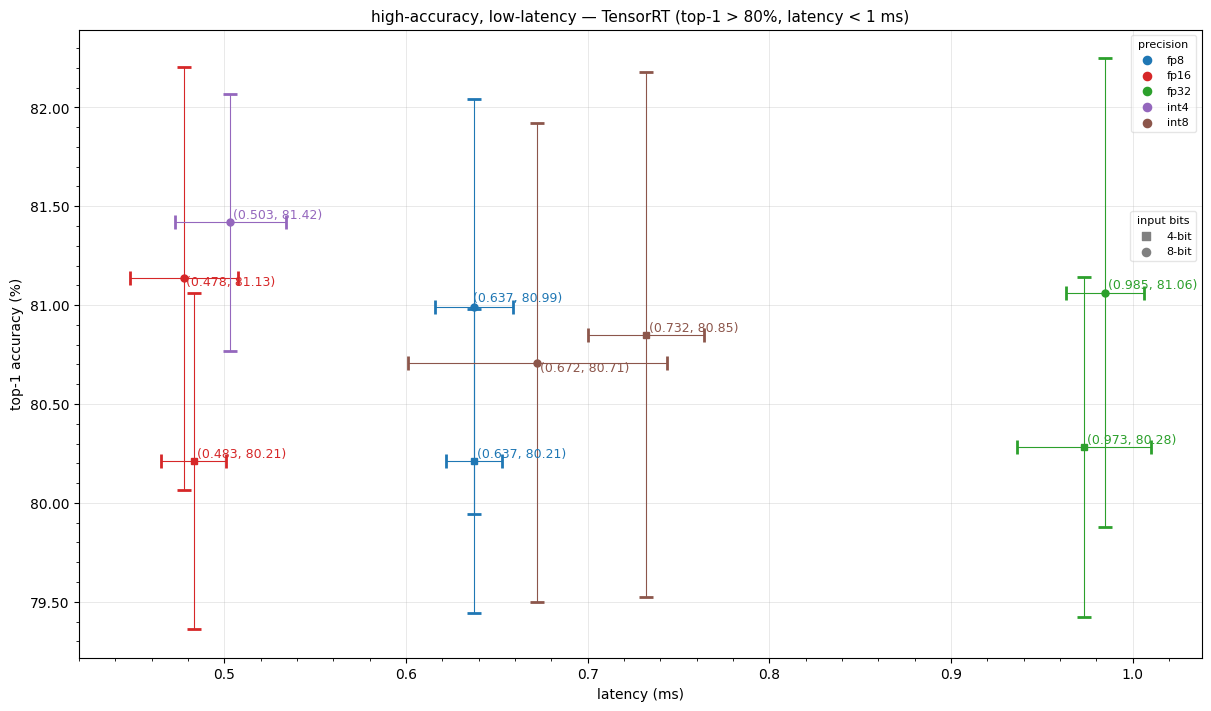

In [28]:
# Plot 5 — zoomed TensorRT scatter (top1 > 80%, latency < 1 ms)
from adjustText import adjust_text

BIT_MARKERS = {4: "s", 8: "o"}

zoom_data = table[
    (table["backend"] == "tensorrt") &
    (table["input_bits"].isin([4, 8])) &
    (table["top1_mean"] > 80) &
    (table["lat_ms_mean"] < 1)
]

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

texts = []
for _, row in zoom_data.iterrows():
    color  = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    marker = BIT_MARKERS.get(int(row["input_bits"]), "o")
    xerr_lo = min(row["lat_ms_std"], row["lat_ms_mean"])
    ax.errorbar(row["lat_ms_mean"], row["top1_mean"],
                xerr=[[xerr_lo], [row["lat_ms_std"]]],
                yerr=row["top1_std"],
                fmt=marker, color=color, markersize=5,
                elinewidth=0.8, capsize=5, capthick=2.0, linewidth=0, zorder=3)
    texts.append(ax.text(
        row["lat_ms_mean"], row["top1_mean"],
        f"({row['lat_ms_mean']:.3f}, {row['top1_mean']:.2f})",
        fontsize=9, color=color, zorder=4,
    ))

ax.set_xlabel("latency (ms)")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("high-accuracy, low-latency — TensorRT (top-1 > 80%, latency < 1 ms)", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

adjust_text(
    texts, ax=ax,
    expand_points=(1.4, 1.6), expand_text=(1.2, 1.4),
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6),
)

prec_handles = [
    plt.scatter([], [], color=PREC_PALETTE[p], marker="o", s=35, label=p)
    for p in PREC_PALETTE if p in zoom_data["precision"].values
]
legend1 = ax.legend(handles=prec_handles, title="precision",
                    loc="upper right", fontsize=8, title_fontsize=8, framealpha=0.5)
ax.add_artist(legend1)

bits_handles = [
    plt.scatter([], [], color="gray", marker=m, s=35, label=f"{b}-bit")
    for b, m in BIT_MARKERS.items()
]
ax.legend(handles=bits_handles, title="input bits",
          bbox_to_anchor=(1, 0.72), loc="upper right",
          fontsize=8, title_fontsize=8, framealpha=0.5)

plt.show()

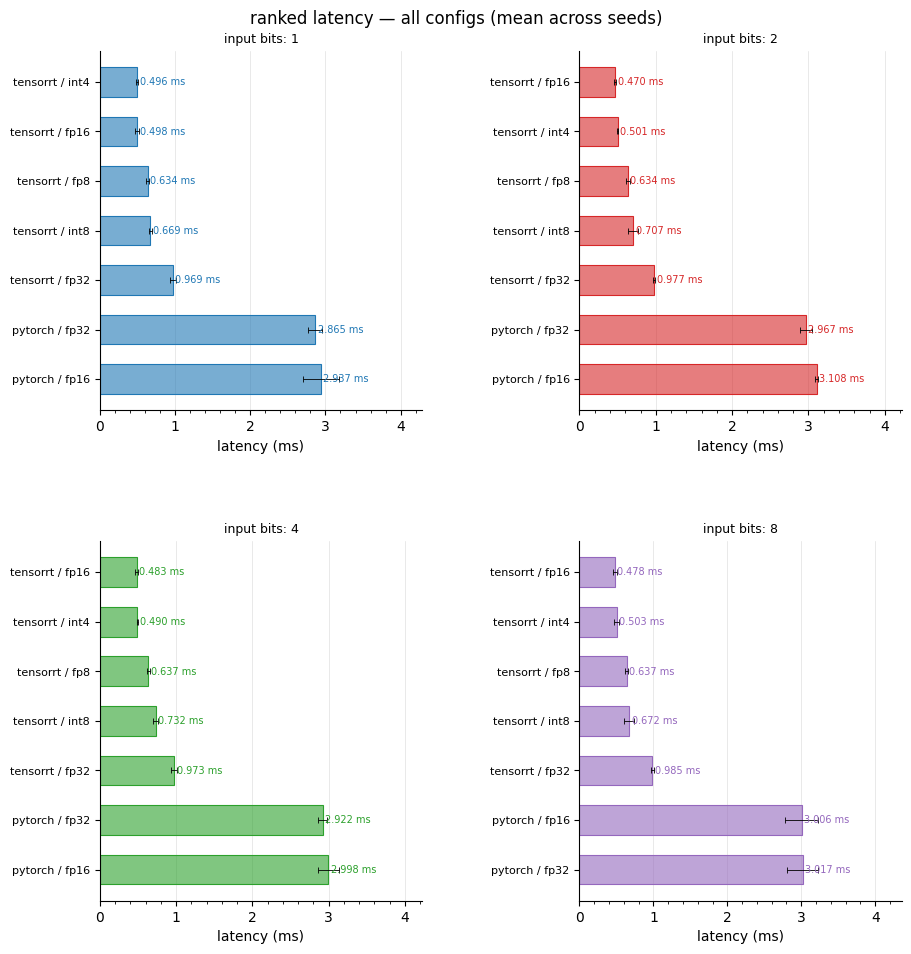

In [29]:
# Plot 6 — ranked latency chart (one subplot per input_bits)
ranked = table.sort_values("lat_ms_mean").reset_index(drop=True)
ranked["label"] = ranked["backend"] + " / " + ranked["precision"]
ranked["input_bits"] = ranked["input_bits"].astype(int)

active_bits = sorted(ranked["input_bits"].unique())
n = len(active_bits)
nrows = math.ceil(n / COLS)

fig, axes = plt.subplots(nrows, COLS, figsize=(4.5 * COLS, 0),
                          constrained_layout=True, squeeze=False)
max_bars = ranked.groupby("input_bits").size().max()
fig.set_size_inches(4.5 * COLS, max_bars * 0.55 * nrows + 1.5)
fig.suptitle("ranked latency — all configs (mean across seeds)", fontsize=12,
             x=0.5, ha="center", y=1.02)
fig.set_constrained_layout_pads(wspace=0.15, hspace=0.15)

ax_flat = axes.flatten()
for idx in range(n, len(ax_flat)):
    ax_flat[idx].set_visible(False)

for ax, bits in zip(ax_flat, active_bits):
    grp = ranked[ranked["input_bits"] == bits].sort_values("lat_ms_mean").reset_index(drop=True)
    if grp.empty:
        ax.set_visible(False)
        continue

    color = BIT_PALETTE.get(bits, "#7f7f7f")
    y_pos = np.arange(len(grp))

    ax.barh(y_pos, grp["lat_ms_mean"],
            xerr=grp["lat_ms_std"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.6, zorder=2,
            error_kw=dict(capsize=2, capthick=0.6, elinewidth=0.6))

    for yi, (_, row) in enumerate(grp.iterrows()):
        ax.text(row["lat_ms_mean"] + ax.get_xlim()[1] * 0.01, yi,
                f"{row['lat_ms_mean']:.3f} ms",
                ha="left", va="center", fontsize=7, color=color, zorder=4)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(grp["label"], fontsize=8)
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.set_xlabel("latency (ms)")
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, (grp["lat_ms_mean"] + grp["lat_ms_std"]).max() * 1.35)

plt.show()

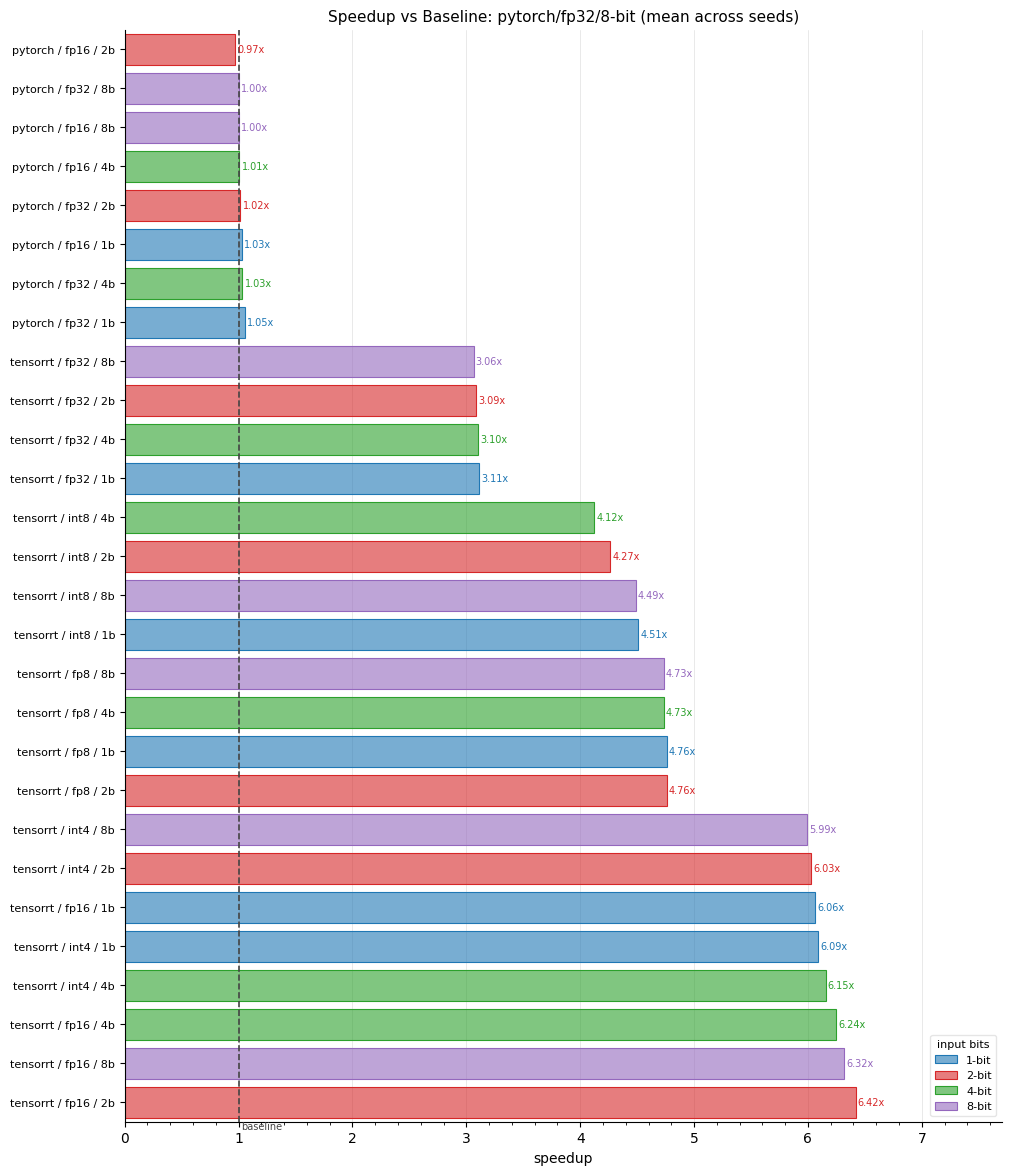

In [30]:
# Plot 7 — speedup vs baseline (pytorch / fp32 / 8-bit)
baseline = table[
    (table["backend"] == "pytorch") &
    (table["precision"] == "fp32") &
    (table["input_bits"] == 8)
]["lat_ms_mean"].values[0]

speedup = table.copy()
speedup["speedup"]    = baseline / speedup["lat_ms_mean"]
speedup["label"]      = (speedup["backend"] + " / " +
                         speedup["precision"] + " / " +
                         speedup["input_bits"].astype(int).astype(str) + "b")
speedup["input_bits"] = speedup["input_bits"].astype(int)
speedup = speedup.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup.iterrows()):
    bits  = int(row["input_bits"])
    color = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}x",
            ha="left", va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=1.0, color="#444444", linewidth=1.2,
           linestyle="--", zorder=3, label="baseline")
ax.text(1.02, len(speedup) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#444444")

ax.set_yticks(np.arange(len(speedup)))
ax.set_yticklabels(speedup["label"], fontsize=8)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline: pytorch/fp32/8-bit (mean across seeds)", fontsize=11)
ax.set_xlim(0, speedup["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_bits = sorted(b for b in BIT_PALETTE if b in speedup["input_bits"].values)
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=BIT_PALETTE[b] + "99",
                  edgecolor=BIT_PALETTE[b], linewidth=0.8,
                  label=f"{b}-bit")
    for b in present_bits
]
ax.legend(handles=handles, title="input bits", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

In [31]:
out_path = PROJECT_ROOT / "results" / "test_avg_results.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
table.to_json(out_path, orient="records", indent=2)
print(f"Saved to {out_path}")

Saved to /home/pf4636/code/resnet/quantized_resnets/results/test_avg_results.json
